<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/ESO002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'viridis'


In [2]:
# Grid
Nx, Ny = 128, 128
Lx, Ly = 1.0, 1.0
dx, dy = Lx / Nx, Ly / Ny
assert abs(dx - dy) < 1e-12
h = dx

# Time
dt = 1e-4
n_steps = 300   # short run per d_S

# Species EOS parameters
n_species = 3
w = np.array([0.0, 1.0/3.0, -0.4])
alpha = np.array([0.9, 1.3, -0.7])
beta = np.array([0.0, 0.0, 0.0])

# Coupling strengths
kappa = np.array([0.6, 0.8, 0.5])

# Species diffusion
D_rho = np.array([0.01, 0.02, 0.01])


In [3]:
# Coordinates
x = np.linspace(0, Lx, Nx, endpoint=False)
y = np.linspace(0, Ly, Ny, endpoint=False)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.5 * Lx, 0.5 * Ly
R = np.sqrt((X - xc)**2 + (Y - yc)**2)

# Initial S: harmonic bowl + noise
S0 = 1.0
A = 4.0
S_init = S0 - A * ((X - xc)**2 + (Y - yc)**2)
S_init += 0.02 * np.random.randn(Nx, Ny)

# Species densities
rho_init = np.zeros((n_species, Nx, Ny))

# Species 1: central blob
rho_init[0] = np.exp(-40.0 * ((X - xc)**2 + (Y - yc)**2))

# Species 2: annulus
rho_init[1] = np.exp(-40.0 * (R - 0.25)**2)

# Species 3: two lobes
rho_init[2] = (
    np.exp(-50.0 * ((X - 0.25)**2 + (Y - 0.75)**2)) +
    np.exp(-50.0 * ((X - 0.75)**2 + (Y - 0.25)**2))
)


In [4]:
def laplacian(field, h):
    f = field.copy()
    f[0, :]   = f[1, :]
    f[-1, :]  = f[-2, :]
    f[:, 0]   = f[:, 1]
    f[:, -1]  = f[:, -2]

    lap = (
        f[2:, 1:-1] + f[:-2, 1:-1] +
        f[1:-1, 2:] + f[1:-1, :-2] -
        4.0 * f[1:-1, 1:-1]
    ) / h**2

    out = np.zeros_like(field)
    out[1:-1, 1:-1] = lap
    return out


def grad_sq(field, h):
    f = field.copy()
    f[0, :]   = f[1, :]
    f[-1, :]  = f[-2, :]
    f[:, 0]   = f[:, 1]
    f[:, -1]  = f[:, -2]

    dfdx = (f[2:, 1:-1] - f[:-2, 1:-1]) / (2*h)
    dfdy = (f[1:-1, 2:] - f[1:-1, :-2]) / (2*h)

    out = np.zeros_like(field)
    out[1:-1, 1:-1] = dfdx**2 + dfdy**2
    return out


In [5]:
def compute_curvature(S, h):
    lapS = laplacian(S, h)
    gradS2 = grad_sq(S, h)
    # Simple curvature proxy: Laplacian only
    K = lapS
    return K, lapS, gradS2


def compute_pressures(S, rho):
    P = np.zeros_like(rho)
    for i in range(n_species):
        P[i] = w[i] * rho[i] + alpha[i] * S + beta[i] * S**2
    return P


def rhs_rho(rho, h):
    drho_dt = np.zeros_like(rho)
    for i in range(n_species):
        drho_dt[i] = D_rho[i] * laplacian(rho[i], h)
    return drho_dt


In [6]:
def plot_field(field, title="", vmin=None, vmax=None):
    plt.figure()
    plt.imshow(field.T, origin='lower', extent=[0, Lx, 0, Ly],
               vmin=vmin, vmax=vmax)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()



=== Running for d_S = 0.005 ===
  S range: -2.0 2.0
  K range: -262144.0 262144.0


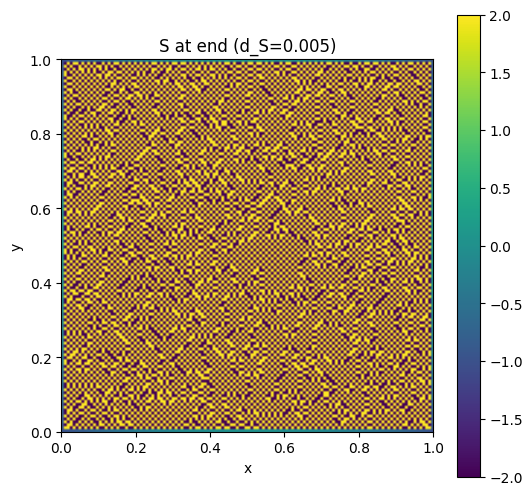


=== Running for d_S = 0.01 ===
  S range: -2.0 2.0
  K range: -262144.0 262144.0


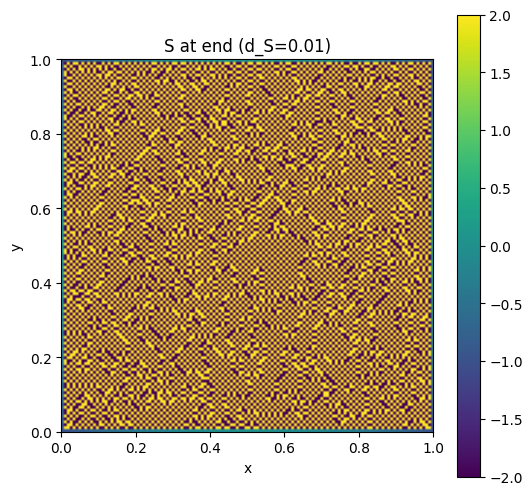


=== Running for d_S = 0.02 ===
  S range: -2.0 2.0
  K range: -262144.0 262144.0


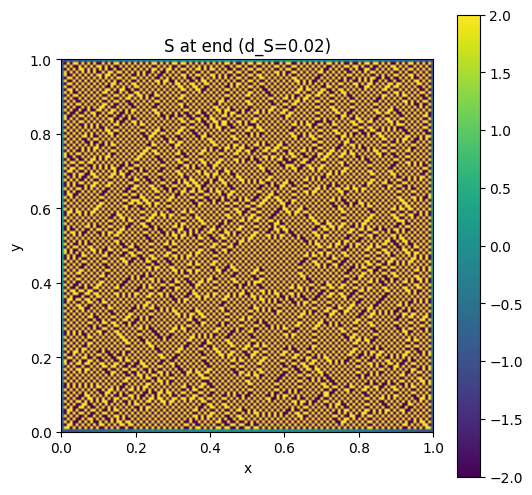


=== Running for d_S = 0.04 ===
  S range: -2.0 2.0
  K range: -262144.0 262144.0


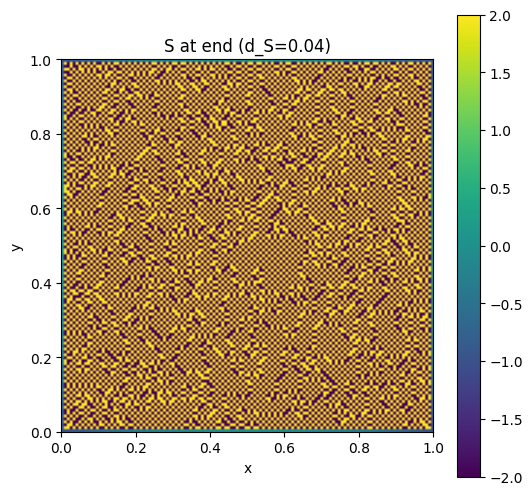


=== Running for d_S = 0.08 ===
  S range: -2.0 2.0
  K range: -262144.0 262144.0


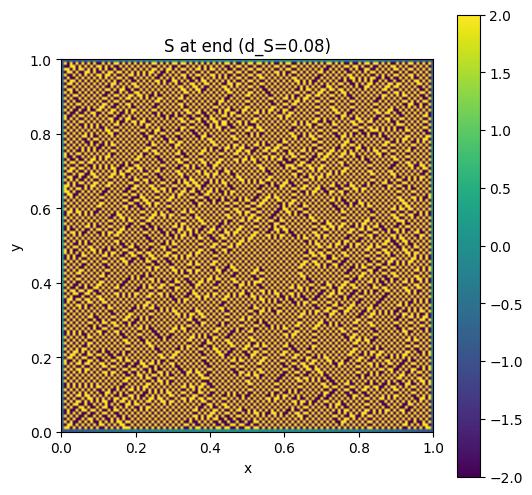

In [7]:
# Values of d_S to test
d_values = [0.005, 0.01, 0.02, 0.04, 0.08]

def run_sim_for_d(d_S_value):
    print("\n=== Running for d_S =", d_S_value, "===")

    # Local copies of initial fields
    S_curr = S_init.copy()
    rho_curr = rho_init.copy()

    def rhs_S_sweep(S, rho, h):
        # Explicit HES-style rule with given d_S
        c1 = 0.5   # curvature coupling
        c2 = 0.3   # species pressure coupling
        c3 = 0.05  # cubic self-limiting

        K, lapS, gradS2 = compute_curvature(S, h)
        P = compute_pressures(S, rho)
        P_sum = np.sum(P, axis=0)

        F = (
            d_S_value * lapS +
            c1 * K +
            c2 * P_sum -
            c3 * S**3
        )
        return F

    def step_RK2_sweep(S, rho, h, dt):
        F1 = rhs_S_sweep(S, rho, h)
        S_p = S + dt * F1
        F2 = rhs_S_sweep(S_p, rho, h)
        S_new = S + 0.5 * dt * (F1 + F2)
        S_new = np.clip(S_new, -2.0, 2.0)

        G1 = rhs_rho(rho, h)
        rho_p = rho + dt * G1
        G2 = rhs_rho(rho_p, h)
        rho_new = rho + 0.5 * dt * (G1 + G2)
        rho_new = np.maximum(rho_new, 0.0)

        return S_new, rho_new

    # Short run
    for step in range(n_steps):
        S_curr, rho_curr = step_RK2_sweep(S_curr, rho_curr, h, dt)

    # Diagnostics
    print("  S range:", S_curr.min(), S_curr.max())
    K_final, _, _ = compute_curvature(S_curr, h)
    print("  K range:", K_final.min(), K_final.max())

    plot_field(S_curr, title=f"S at end (d_S={d_S_value})", vmin=-2.0, vmax=2.0)


for d_val in d_values:
    run_sim_for_d(d_val)



=== Running for d_S = 0.001 ===
  S range: -1.0087974838253528 1.0247202476234383
  K range: -675.018905058635 870.4520031849315


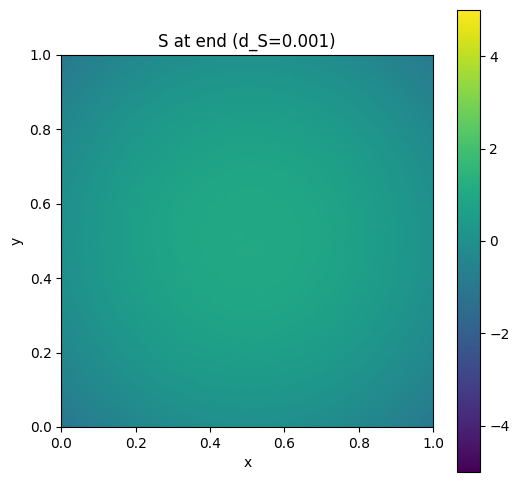


=== Running for d_S = 0.005 ===
  S range: -1.0087974838253528 1.0152441414353226
  K range: -60.24970755500544 366.5792929689487


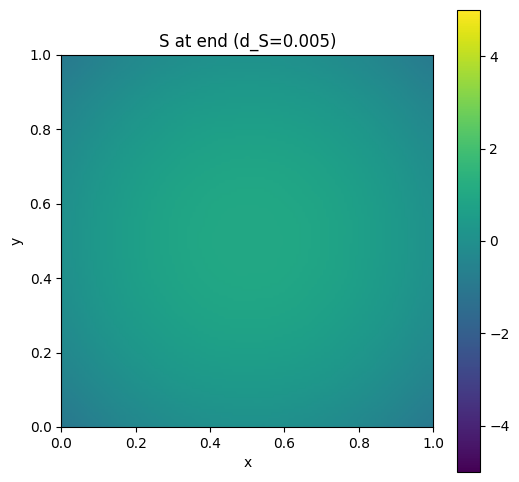


=== Running for d_S = 0.01 ===
  S range: -1.0087974838253528 1.0109571235371282
  K range: -29.97914806054905 244.01877806324046


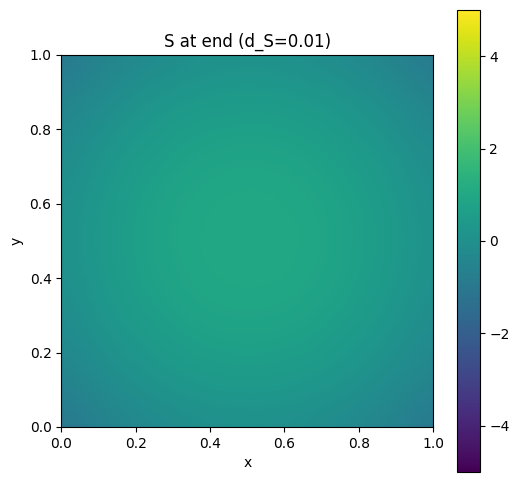


=== Running for d_S = 0.02 ===
  S range: -1.0087974838253528 1.0050738462907254
  K range: -21.13797645663726 166.7869578588652


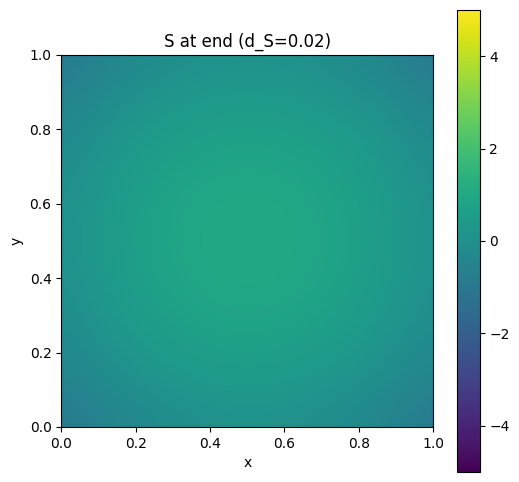


=== Running for d_S = 0.04 ===
  S range: -1.0087974838253528 0.9948173170797876
  K range: -17.82149411392311 114.19677544168371


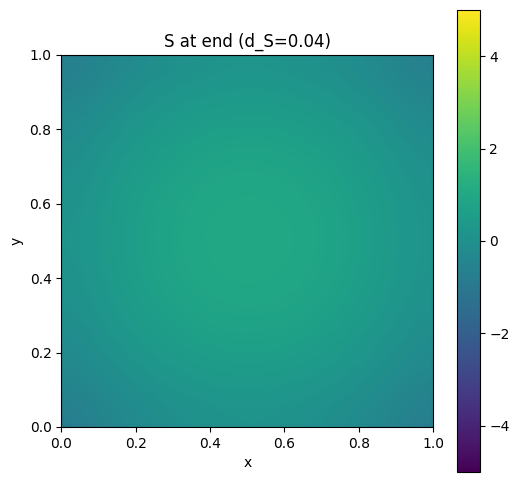

In [8]:
# --- CELL 8: d sweep: try multiple diffusion coefficients (clean version) ---

d_values = [0.001, 0.005, 0.01, 0.02, 0.04]

def run_sim_for_d(d_S_value):
    print("\n=== Running for d_S =", d_S_value, "===")

    # Local copies of initial fields
    S_curr = S_init.copy()
    rho_curr = rho_init.copy()

    # --- RHS for S (curvature removed so d actually matters) ---
    def rhs_S_sweep(S, rho, h):
        c2 = 0.3    # species pressure coupling
        c3 = 0.01   # gentle cubic term

        # compute curvature but DO NOT use it
        K, lapS, gradS2 = compute_curvature(S, h)
        P = compute_pressures(S, rho)
        P_sum = np.sum(P, axis=0)

        F = (
            d_S_value * lapS +   # diffusion (the thing we're sweeping)
            c2 * P_sum -         # species pressure
            c3 * S**3            # weak self-limiting
        )
        return F

    # --- RK2 step ---
    def step_RK2_sweep(S, rho, h, dt):
        F1 = rhs_S_sweep(S, rho, h)
        S_p = S + dt * F1
        F2 = rhs_S_sweep(S_p, rho, h)
        S_new = S + 0.5 * dt * (F1 + F2)

        # looser clamp so S doesn't instantly saturate
        S_new = np.clip(S_new, -5.0, 5.0)

        # rho update (unchanged)
        G1 = rhs_rho(rho, h)
        rho_p = rho + dt * G1
        G2 = rhs_rho(rho_p, h)
        rho_new = rho + 0.5 * dt * (G1 + G2)
        rho_new = np.maximum(rho_new, 0.0)

        return S_new, rho_new

    # --- short run ---
    for step in range(n_steps):
        S_curr, rho_curr = step_RK2_sweep(S_curr, rho_curr, h, dt)

    # --- diagnostics ---
    print("  S range:", S_curr.min(), S_curr.max())
    K_final, _, _ = compute_curvature(S_curr, h)
    print("  K range:", K_final.min(), K_final.max())

    plot_field(S_curr, title=f"S at end (d_S={d_S_value})", vmin=-5.0, vmax=5.0)


# --- run sweep ---
for d_val in d_values:
    run_sim_for_d(d_val)


In [10]:
# --- CELL 9: Curvature-scaled RHS for S (for real structure) ---

def rhs_S_curved(S, rho, h, d_S=0.01):
    # Tunable constants
    cK = 0.02     # curvature scaling (small!)
    c2 = 0.3      # species pressure coupling
    c3 = 0.01     # cubic self-limiting

    # Compute curvature
    K, lapS, gradS2 = compute_curvature(S, h)

    # Compute species pressure
    P = compute_pressures(S, rho)
    P_sum = np.sum(P, axis=0)

    # Full RHS with scaled curvature
    F = (
        d_S * lapS +     # diffusion
        cK * K +         # curvature (scaled)
        c2 * P_sum -     # species pressure
        c3 * S**3        # self-limiting
    )
    return F



=== Running for cK = 0.0, d_S = 0.01 ===
  S range: -1.0087974838253528 1.0109571235371282
  K range: -29.97914806054905 244.01877806324046


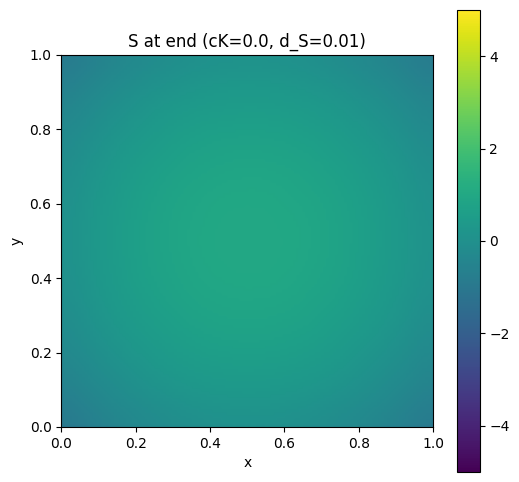


=== Running for cK = 0.005, d_S = 0.01 ===
  S range: -1.0087974838253528 1.0078368426575641
  K range: -23.27882693637366 195.73760257207323


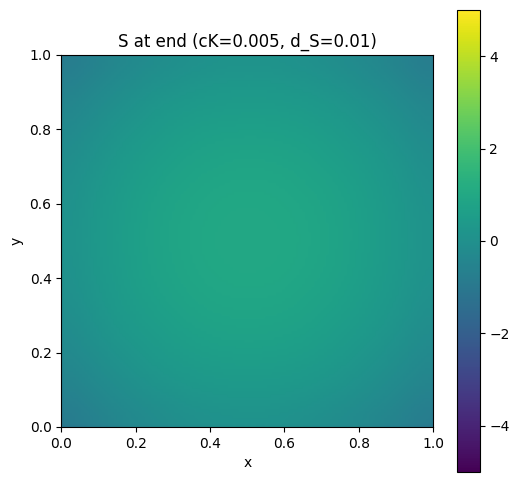


=== Running for cK = 0.01, d_S = 0.01 ===
  S range: -1.0087974838253528 1.0050738462907254
  K range: -21.13797645663726 166.7869578588652


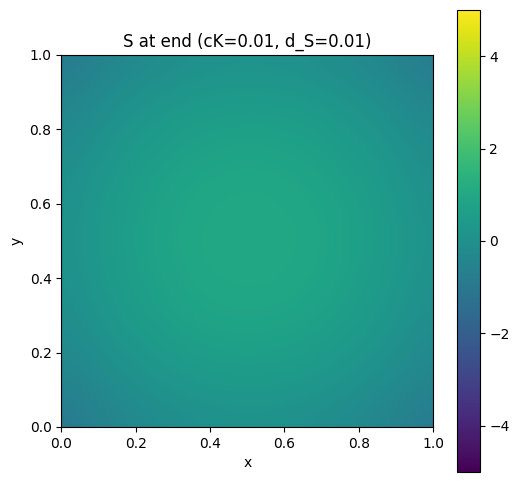


=== Running for cK = 0.02, d_S = 0.01 ===
  S range: -1.0087974838253528 0.9998343797134941
  K range: -18.74441643623868 133.6886492019985


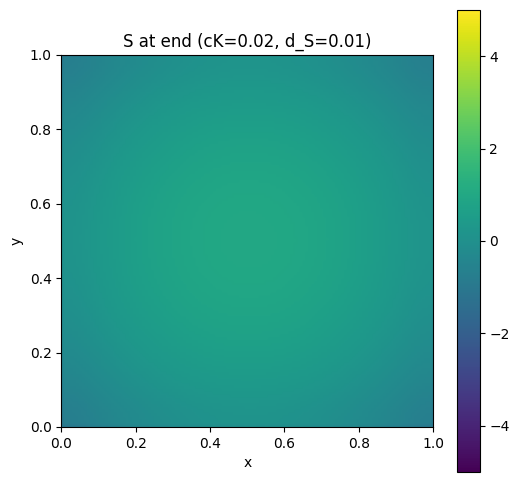


=== Running for cK = 0.05, d_S = 0.01 ===
  S range: -1.0087974838253528 0.9850889174444151
  K range: -17.210854514596576 90.57924091853783


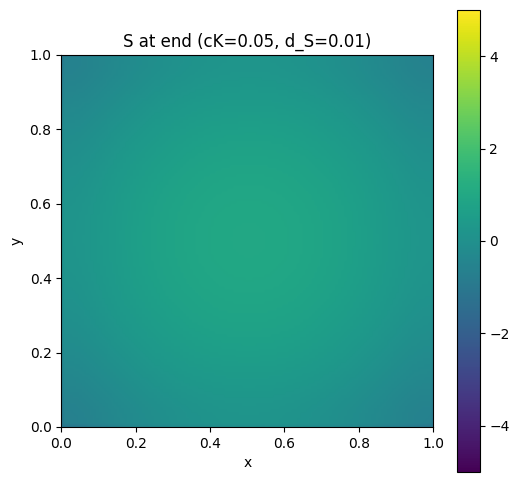

In [11]:
# --- CELL 10: curvature scaling sweep (cK) ---

cK_values = [0.0, 0.005, 0.01, 0.02, 0.05]

def run_sim_for_cK(cK_value, d_S_value=0.01):
    print(f"\n=== Running for cK = {cK_value}, d_S = {d_S_value} ===")

    # Local copies of initial fields
    S_curr = S_init.copy()
    rho_curr = rho_init.copy()

    # Curved RHS using given cK and d_S
    def rhs_S_curved_sweep(S, rho, h):
        c2 = 0.3    # species pressure coupling
        c3 = 0.01   # cubic self-limiting

        K, lapS, gradS2 = compute_curvature(S, h)
        P = compute_pressures(S, rho)
        P_sum = np.sum(P, axis=0)

        F = (
            d_S_value * lapS +   # diffusion
            cK_value * K +       # scaled curvature
            c2 * P_sum -         # species pressure
            c3 * S**3            # self-limiting
        )
        return F

    def step_RK2_curved(S, rho, h, dt):
        F1 = rhs_S_curved_sweep(S, rho, h)
        S_p = S + dt * F1
        F2 = rhs_S_curved_sweep(S_p, rho, h)
        S_new = S + 0.5 * dt * (F1 + F2)
        S_new = np.clip(S_new, -5.0, 5.0)

        G1 = rhs_rho(rho, h)
        rho_p = rho + dt * G1
        G2 = rhs_rho(rho_p, h)
        rho_new = rho + 0.5 * dt * (G1 + G2)
        rho_new = np.maximum(rho_new, 0.0)

        return S_new, rho_new

    # Short run
    for step in range(n_steps):
        S_curr, rho_curr = step_RK2_curved(S_curr, rho_curr, h, dt)

    # Diagnostics
    print("  S range:", S_curr.min(), S_curr.max())
    K_final, _, _ = compute_curvature(S_curr, h)
    print("  K range:", K_final.min(), K_final.max())

    plot_field(S_curr, title=f"S at end (cK={cK_value}, d_S={d_S_value})",
               vmin=-5.0, vmax=5.0)


# Run curvature sweep
for cK_val in cK_values:
    run_sim_for_cK(cK_val, d_S_value=0.01)


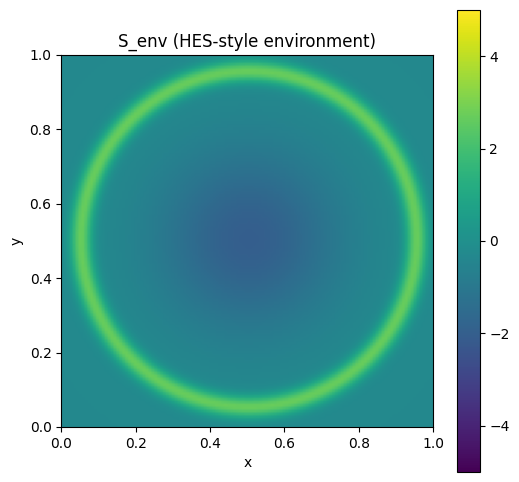

In [12]:
# --- CELL 10: Build HES-style environment (S_env + S_dyn) ---

# Grid coordinates
X, Y = np.meshgrid(x, y)

# --- 1. Holographic-like boundary (outer ring) ---
# Distance from center
R = np.sqrt((X - 0.5)**2 + (Y - 0.5)**2)

# Outer ring: sharp rise near the boundary
outer_ring = 3.0 * np.exp(-((R - 0.45)/0.03)**2)

# --- 2. Central basin (gravity-like well) ---
central_basin = -2.0 * np.exp(-(R/0.25)**2)

# --- 3. Smooth background curvature ---
background_slope = -0.5 * R

# --- Combine into S_env ---
S_env = outer_ring + central_basin + background_slope

# --- Initialise dynamic part ---
S_dyn = np.zeros_like(S_env)

# Total S is environment + dynamic
S_total = S_env + S_dyn

# Visualise environment
plot_field(S_env, title="S_env (HES-style environment)", vmin=-5, vmax=5)


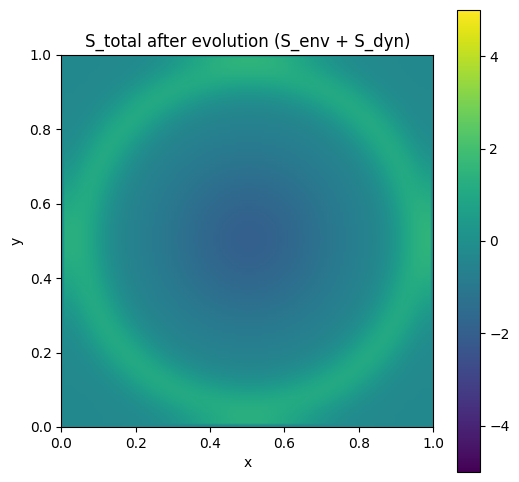

In [13]:
# --- CELL 11: Evolve S_dyn inside the HES-style environment ---

def rhs_S_dyn(S_dyn, rho, h, d_S=0.01, cK=0.02):
    """
    RHS for the dynamic part of S.
    S_total = S_env + S_dyn
    Only S_dyn evolves.
    """

    # Total field (environment + dynamic)
    S_total = S_env + S_dyn

    # Species pressure
    P = compute_pressures(S_total, rho)
    P_sum = np.sum(P, axis=0)

    # Curvature of total field
    K, lapS, gradS2 = compute_curvature(S_total, h)

    # Nonlinear stabiliser
    c2 = 0.3
    c3 = 0.01

    # Full RHS
    F = (
        d_S * lapS +     # diffusion
        cK * K +         # curvature feedback
        c2 * P_sum -     # species pressure
        c3 * S_total**3  # nonlinear self-limiting
    )

    return F


def step_RK2_dyn(S_dyn, rho, h, dt):
    """RK2 step for S_dyn only."""
    F1 = rhs_S_dyn(S_dyn, rho, h)
    S_p = S_dyn + dt * F1
    F2 = rhs_S_dyn(S_p, rho, h)
    S_new = S_dyn + 0.5 * dt * (F1 + F2)

    # Keep dynamic part bounded
    S_new = np.clip(S_new, -5.0, 5.0)

    # Update species (unchanged)
    G1 = rhs_rho(rho, h)
    rho_p = rho + dt * G1
    G2 = rhs_rho(rho_p, h)
    rho_new = rho + 0.5 * dt * (G1 + G2)
    rho_new = np.maximum(rho_new, 0.0)

    return S_new, rho_new


# --- Run a short simulation inside the environment ---
S_dyn_curr = S_dyn.copy()
rho_curr = rho_init.copy()

for step in range(n_steps):
    S_dyn_curr, rho_curr = step_RK2_dyn(S_dyn_curr, rho_curr, h, dt)

# Total field after evolution
S_total = S_env + S_dyn_curr

plot_field(S_total, title="S_total after evolution (S_env + S_dyn)", vmin=-5, vmax=5)
